# Model SARIMA - Sèrie temporal 1

En aquest notebook s’ajusta un model SARIMA per a la sèrie Grip – Barcelona Ciutat – 15 anys o més, seguint la metodologia Box-Jenkins. L’objectiu és obtenir prediccions per al període d’avaluació i valorar-ne el comportament mitjançant mètriques d’error i cobertura dels intervals de predicció.

El procediment és el següent:

1. Identificació del model
2. Estimació del model
3. Validació
4. Predicció

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore', category=DeprecationWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

In [2]:
df_serie = df[
    (df["nom_regio"] == "Barcelona Ciutat") &
    (df["diagnostic"] == "Grip") &
    (df["edat_bin"] == "15+")
    ]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

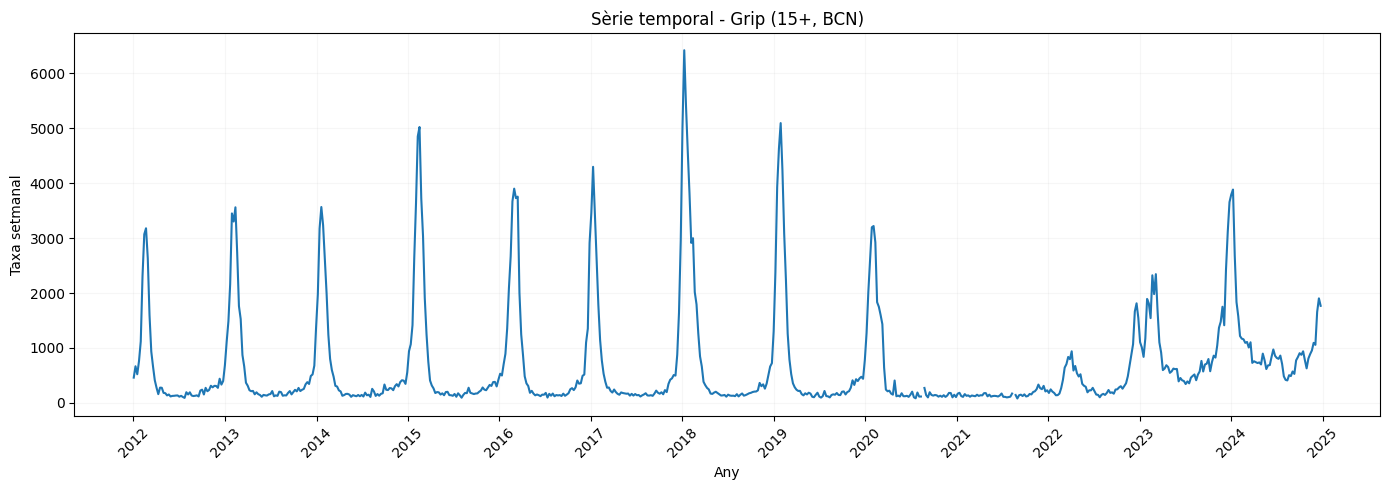

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Sèrie temporal - Grip (15+, BCN)")
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

## Divisió Entrenament-Avaluació

La sèrie es divideix en un conjunt d’entrenament (període 2012-2019) i un conjunt d’avaluació (període 2020-2024)

In [4]:
serie_1 = serie.copy()

train = serie_1[serie_1.index < "2020-01-01"]
test  = serie_1[serie_1.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

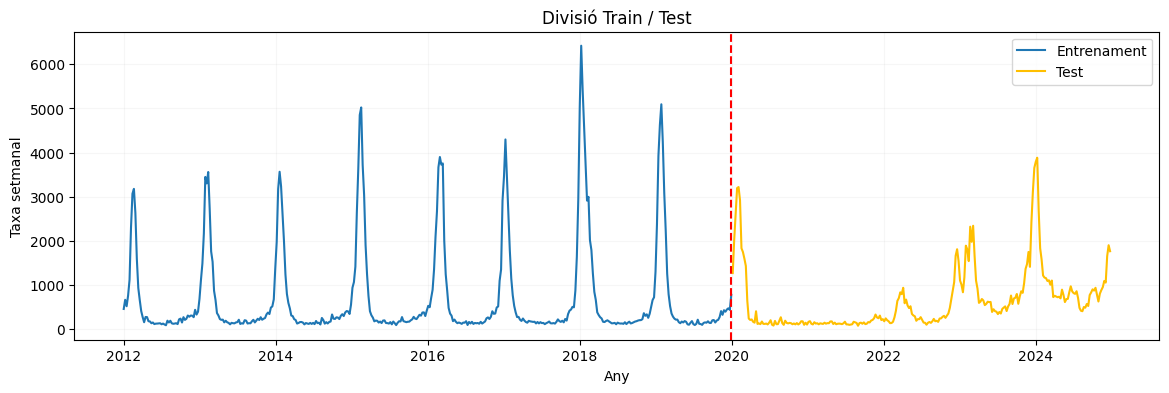

In [5]:
plt.figure(figsize=(14,4))

plt.plot(train, label="Entrenament", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train / Test")
plt.grid(alpha=0.1)
plt.show()

## Identificació del model

En aquesta fase s’analitza la sèrie d’entrenament per determinar les transformacions necessàries i proposar un conjunt reduït de models SARIMA candidats. Es considera l’estabilitat de la mitjana i la variància, la presència d’estacionalitat anual i la necessitat de diferenciació regular i estacional. Finalment, s’analitzen l’ACF i la PACF de la sèrie transformada per identificar els ordres del model.


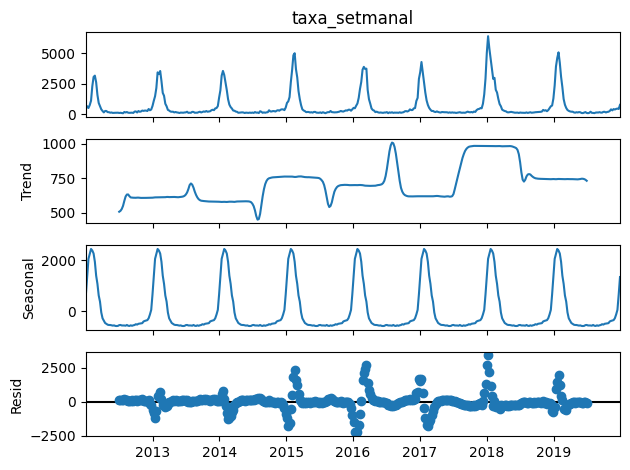

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

### Transformació logarítmica

Es comparen la sèrie original i la sèrie transformada logarítmicament, juntament amb la seva mitjana i variància mòbils. Com que la variabilitat és més elevada en els períodes amb valors més alts, s’utilitza la transformació logarítmica per estabilitzar parcialment la variància.

Mitjana global (train): 686.9091016273319
Variància global (train): 1183896.2579264757

Mitjana per any:
date
2012-12-31    507.288211
2013-12-31    637.395861
2014-12-31    556.079307
2015-12-31    749.084448
2016-12-31    788.935149
2017-12-31    619.561558
2018-12-31    910.160603
2019-12-31    725.928625
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    5.244344e+05
2013-12-31    8.059521e+05
2014-12-31    7.291890e+05
2015-12-31    1.466850e+06
2016-12-31    1.165860e+06
2017-12-31    9.620598e+05
2018-12-31    2.296626e+06
2019-12-31    1.547799e+06
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


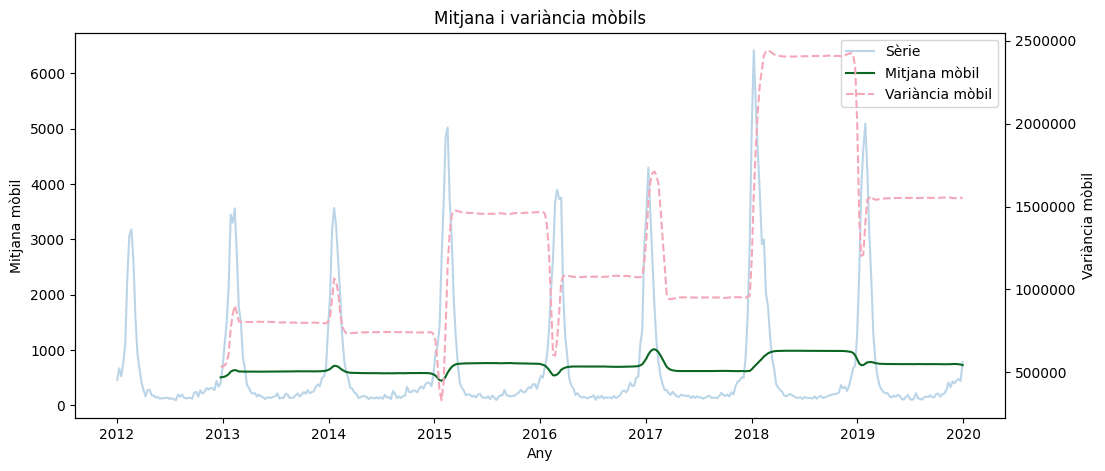

In [7]:
print("Mitjana global (train):", train.mean())
print("Variància global (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\nMitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_mean, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)
ax1.set_xlabel("Any")
ax1.set_ylabel("Mitjana mòbil")
ax2.set_ylabel("Variància mòbil")

plt.title("Mitjana i variància mòbils")
plt.show()

Mitjana global (train_log): 5.809758827482673
Variància global (train_log): 1.107689038078148

 Mitjana per any:
date
2012-12-31    5.688893
2013-12-31    5.828385
2014-12-31    5.701847
2015-12-31    5.857590
2016-12-31    5.970716
2017-12-31    5.740529
2018-12-31    5.923326
2019-12-31    5.766923
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    0.850172
2013-12-31    1.030377
2014-12-31    0.924484
2015-12-31    1.171465
2016-12-31    1.258357
2017-12-31    1.032225
2018-12-31    1.436086
2019-12-31    1.232674
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


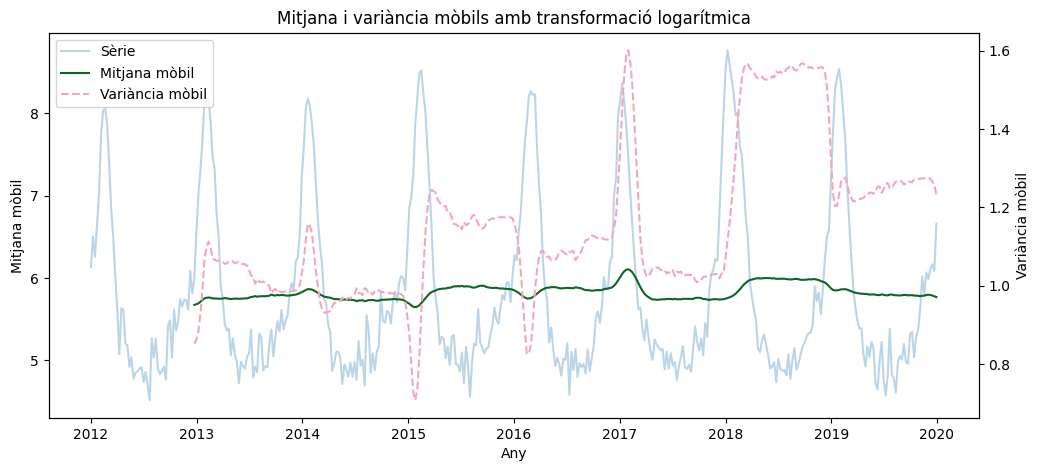

In [8]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print("Mitjana global (train_log):", train_log.mean())
print("Variància global (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\n Mitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_meanlog, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

ax1.set_xlabel("Any")
ax1.set_ylabel("Mitjana mòbil")
ax2.set_ylabel("Variància mòbil")
plt.title("Mitjana i variància mòbils amb transformació logarítmica")
plt.show()

### ACF i diferenciació estacional

A continuació, s’analitza l’ACF de la sèrie logarítmica.
Els pics en retards propers al període anual, m=52, indiquen una dependència estacional clara.

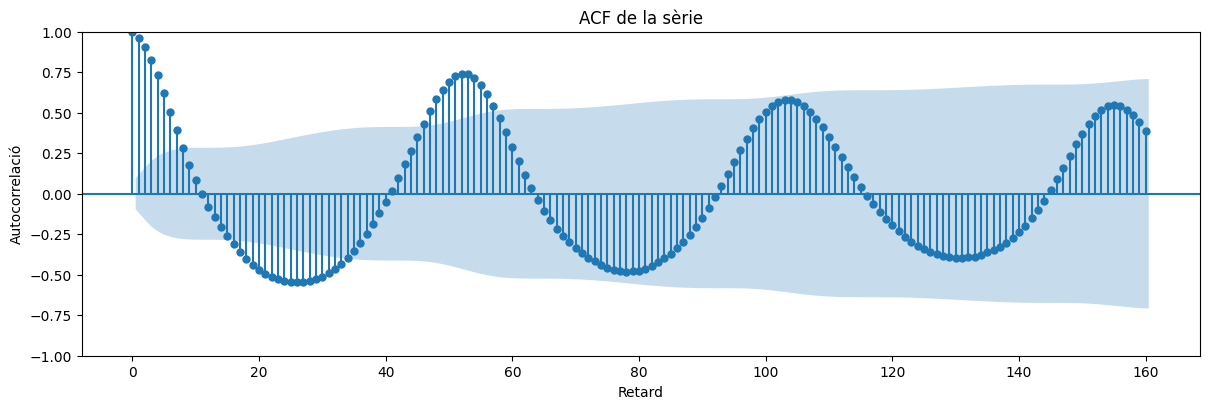

In [9]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF de la sèrie")
plt.tight_layout()
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")

plt.show()

Per comprovar l’efecte de la diferenciació estacional, es compara la sèrie abans i després d’aplicar D=1, així com les seves ACF corresponents. Després de la diferenciació estacional, la dependència anual es redueix de manera substancial. Per tant, es fixa D=1 amb període m=52.

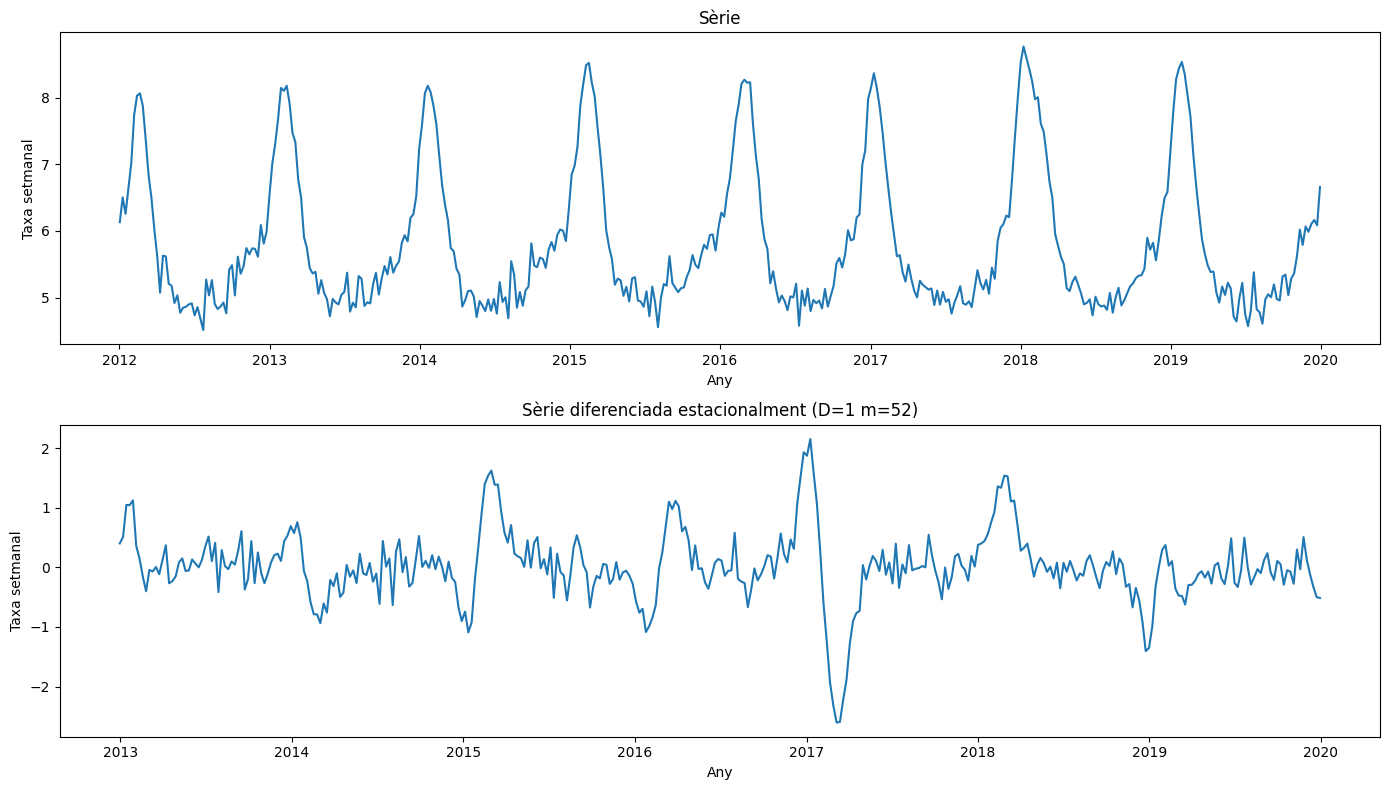

In [10]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Sèrie")
axes[0].set_ylabel("Taxa setmanal")
axes[0].set_xlabel("Any")

axes[1].plot(serie_D1)
axes[1].set_title("Sèrie diferenciada estacionalment (D=1 m=52)")
axes[1].set_ylabel("Taxa setmanal")
axes[1].set_xlabel("Any")

plt.tight_layout()
plt.show()

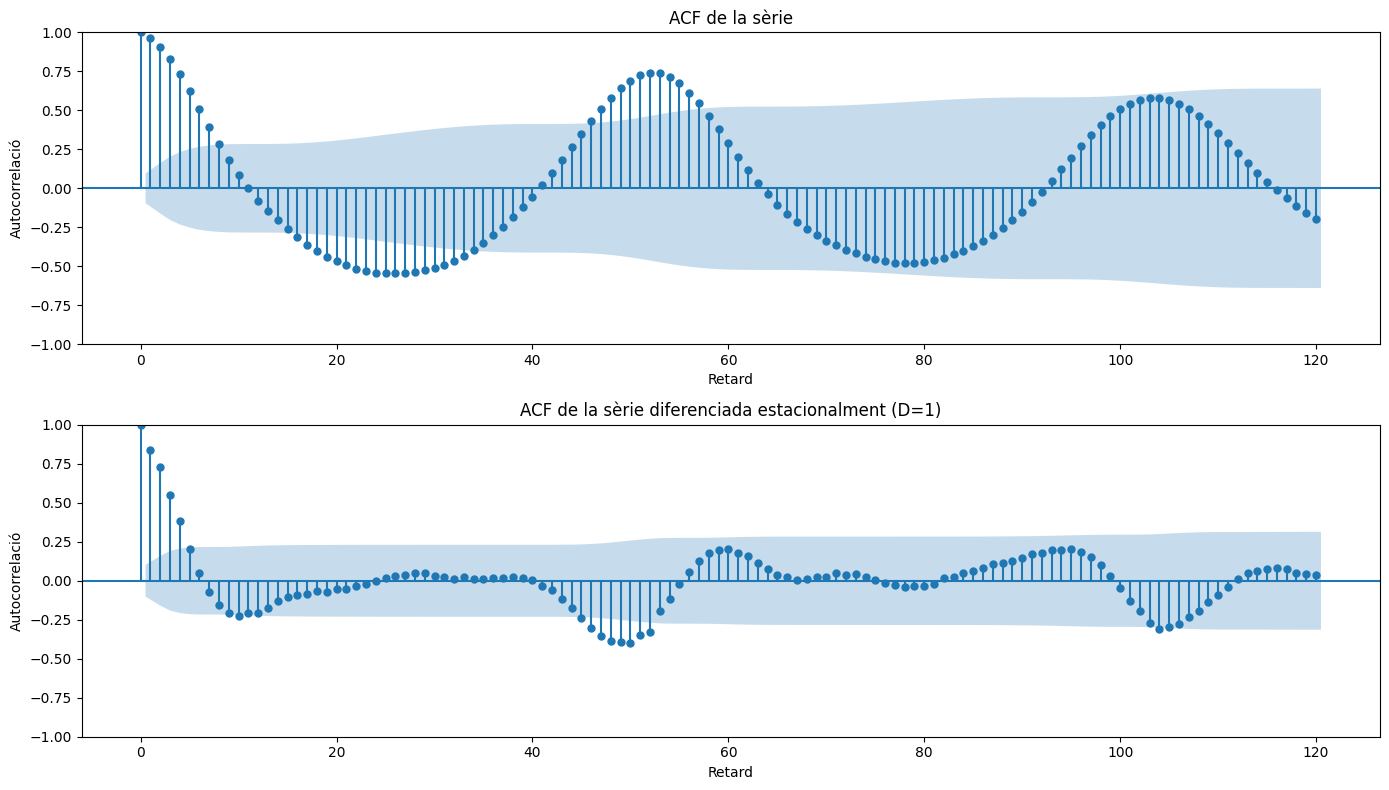

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF de la sèrie")
axes[0].set_xlabel("Retard")
axes[0].set_ylabel("Autocorrelació")


plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF de la sèrie diferenciada estacionalment (D=1)")
axes[1].set_xlabel("Retard")
axes[1].set_ylabel("Autocorrelació")


plt.tight_layout()
plt.show()

### Comprovació de la diferenciació regular

Un cop considerada la transformació logarítmica i la diferenciació estacional, s’avalua si també és necessària una diferenciació regular. Aquesta decisió es basa en si la mitjana és constant, en l'ACF i es reforça mitjançant els tests ADF i KPSS.

In [12]:
adf_pvalor = adfuller(train_log, autolag="AIC")[1]
kpss_pvalor = kpss(train_log, regression="c", nlags="auto")[1]

def format_pvalor(p, test):
    if test == "ADF" and p < 0.001:
        return "< 0.001"
    if test == "KPSS" and p >= 0.10:
        return "> 0.10"
    return f"{p:.4f}"

conclusio_adf = (
    "Es rebutja H0: evidència d’estacionarietat"
    if adf_pvalor < 0.05
    else "No es rebutja H0: possible no estacionarietat"
)

conclusio_kpss = (
    "No es rebutja H0: compatible amb estacionarietat"
    if kpss_pvalor >= 0.05
    else "Es rebutja H0: evidència de no estacionarietat"
)

taula_tests = pd.DataFrame({
    "Test": ["ADF", "KPSS"],
    "p-valor": [
        format_pvalor(adf_pvalor, "ADF"),
        format_pvalor(kpss_pvalor, "KPSS")
    ],
    "Conclusió": [conclusio_adf, conclusio_kpss]
})

taula_tests

/var/folders/gl/4q3h26mn17x5r3shw8dj8t280000gn/T/ipykernel_3386/1130111050.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalor = kpss(train_log, regression="c", nlags="auto")[1]


,Test,p-valor,Conclusió
0,ADF,< 0.001,Es rebutja H0: evidència d’estacionarietat
1,KPSS,> 0.10,No es rebutja H0: compatible amb estacionarietat


Els resultats dels tests no indiquen la necessitat d’aplicar una diferenciació regular. Per tant, es fixa \(d=0\).

### Identificació dels ordres ARMA

Un cop seleccionades la transformació logarítmica i la diferenciació regular i estacional (d=0, D=1), s’analitzen l’ACF i la PACF de la sèrie resultant. A partir d’aquests gràfics es proposen ordres regulars baixos per als components AR i MA, i es consideren també components estacionals simples.

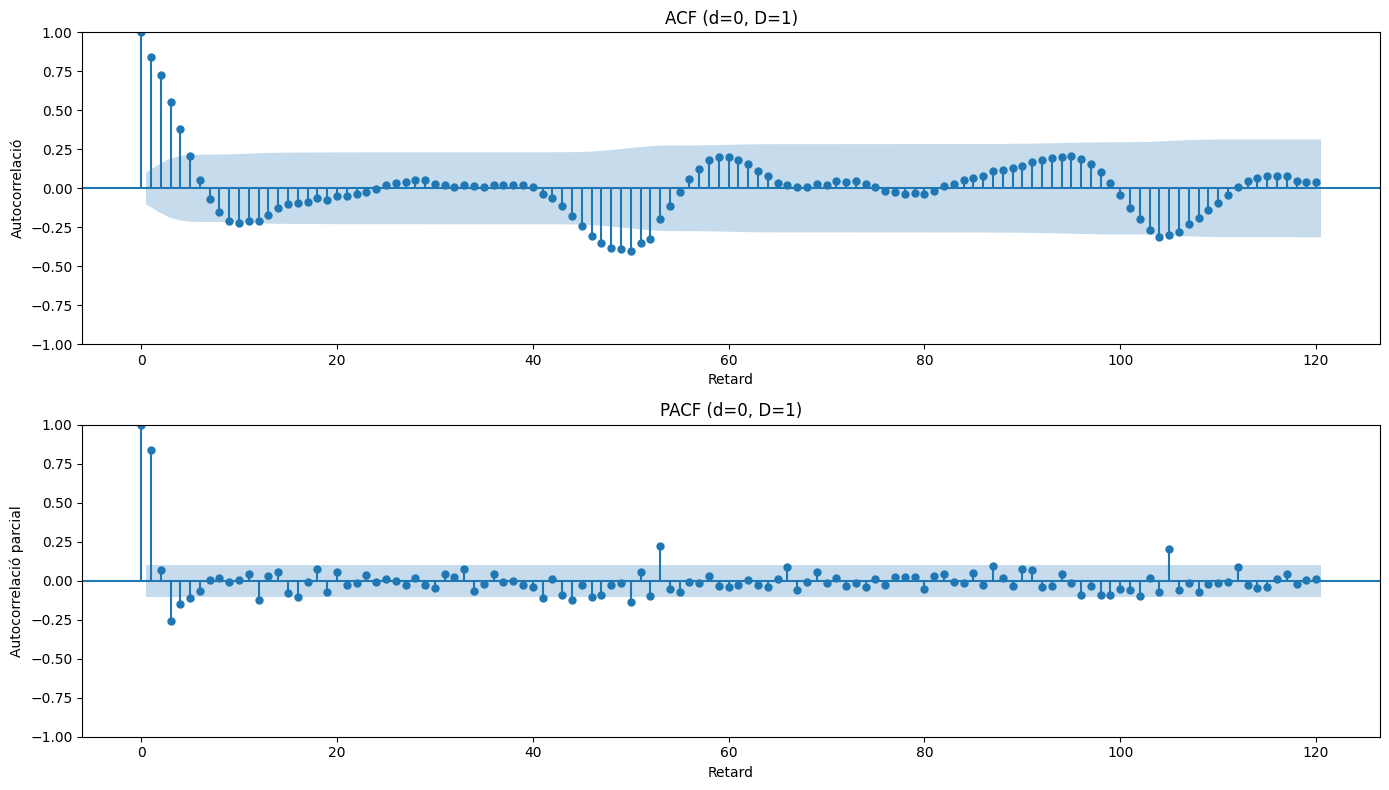

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_D1, lags=120, ax=axes[0])
axes[0].set_title("ACF (d=0, D=1)")
axes[0].set_xlabel("Retard")
axes[0].set_ylabel("Autocorrelació")

plot_pacf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("PACF (d=0, D=1)")
axes[1].set_xlabel("Retard")
axes[1].set_ylabel("Autocorrelació parcial")

plt.tight_layout()
plt.show()

### Anàlisi de l’ACF i la PACF

L’ACF i la PACF mostren dependència a curt termini, compatible amb components ARMA regulars d’ordre baix. Per aquest motiu, en la fase d’estimació es consideren models amb p,q {0,1,2} i P,Q {0,1}, mantenint d=0, D=1 i m=52.

## Estimació dels models candidats

S’ajusten diversos models SARIMA candidats a partir dels ordres identificats amb l’ACF i la PACF. La primera comparació es fa mitjançant l’AIC, amb l’objectiu de retenir un conjunt reduït de models per a la validació residual posterior. 

In [14]:
models = [
    ((1,0,1), (1,1,1,52)),
    ((1,0,1), (0,1,1,52)),
    ((1,0,0), (1,1,1,52)),
    ((1,0,0), (0,1,1,52)),
    ((2,0,1), (1,1,1,52)),
    ((2,0,1), (0,1,1,52)),
    ((2,0,0), (1,1,1,52)),
    ((2,0,0), (0,1,1,52)),
    ((1,0,2), (1,1,1,52)),
    ((1,0,2), (0,1,1,52)),
    ((2,0,2), (1,1,1,52)),
    ((2,0,2), (0,1,1,52)),
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA {order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA {order}{seasonal_order}")

print("\n Millor model:")
print(best_model)
print("AIC:", best_aic)

Model SARIMA (1, 0, 1)(1, 1, 1, 52)
AIC: 73.1674161807755
----------------------------------------
Model SARIMA (1, 0, 1)(0, 1, 1, 52)
AIC: 64.84290174701877
----------------------------------------
Model SARIMA (1, 0, 0)(1, 1, 1, 52)
AIC: 70.88914103240374
----------------------------------------
Model SARIMA (1, 0, 0)(0, 1, 1, 52)
AIC: 62.23344651427435
----------------------------------------
Model SARIMA (2, 0, 1)(1, 1, 1, 52)
AIC: 75.04681063765248
----------------------------------------
Model SARIMA (2, 0, 1)(0, 1, 1, 52)
AIC: 66.8325654040257
----------------------------------------
Model SARIMA (2, 0, 0)(1, 1, 1, 52)
AIC: 73.09054495810173
----------------------------------------
Model SARIMA (2, 0, 0)(0, 1, 1, 52)
AIC: 64.38163549572617
----------------------------------------
Model SARIMA (1, 0, 2)(1, 1, 1, 52)
AIC: 64.14514080873906
----------------------------------------
Model SARIMA (1, 0, 2)(0, 1, 1, 52)
AIC: 52.14786848255116
----------------------------------------
Mo

### Selecció preliminar de models

No es selecciona automàticament el model amb menor AIC. Es retenen els tres models amb millor AIC per comparar-ne també la significació dels coeficients, la parsimònia i el comportament dels residus.

In [15]:
model1 = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 52)   Log Likelihood                 -14.592
Date:                              Mon, 08 Jun 2026   AIC                             41.184
Time:                                      20:51:32   BIC                             63.623
Sample:                                  01-02-2012   HQIC                            50.153
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6713      0.089     18.746      0.000       1.497       1.846
ar.L2         -0.77

In [16]:
model2 = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(1,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2 = model2.fit()
print(result2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 52)   Log Likelihood                 -17.682
Date:                              Mon, 08 Jun 2026   AIC                             49.364
Time:                                      20:51:45   BIC                             75.543
Sample:                                  01-02-2012   HQIC                            59.828
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6960      0.086     19.642      0.000       1.527       1.865
ar.L2         -0.78

In [17]:
model3 = SARIMAX(train_log,
                order=(1,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result3 = model3.fit()
print(result3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 52)   Log Likelihood                 -21.074
Date:                              Mon, 08 Jun 2026   AIC                             52.148
Time:                                      20:51:50   BIC                             70.847
Sample:                                  01-02-2012   HQIC                            59.622
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7824      0.051     15.384      0.000       0.683       0.882
ma.L1          0.05

## Validació dels models preseleccionats

Els tres models preseleccionats s’avaluen mitjançant el diagnòstic dels residus. Es compara el gràfic dels residus, l’ACF dels residus i el contrast de Ljung-Box per retards regulars i estacionals per valorar si els residus es poden considerar aproximadament soroll blanc.

Burn-in utilitzat: 107


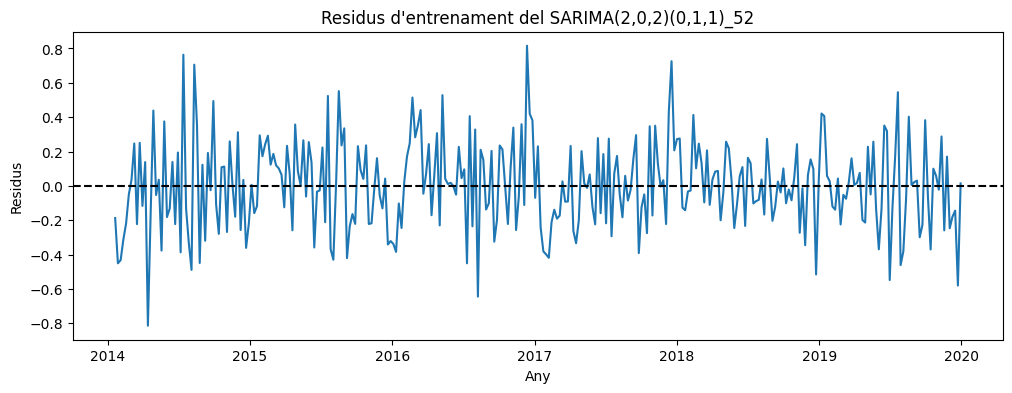

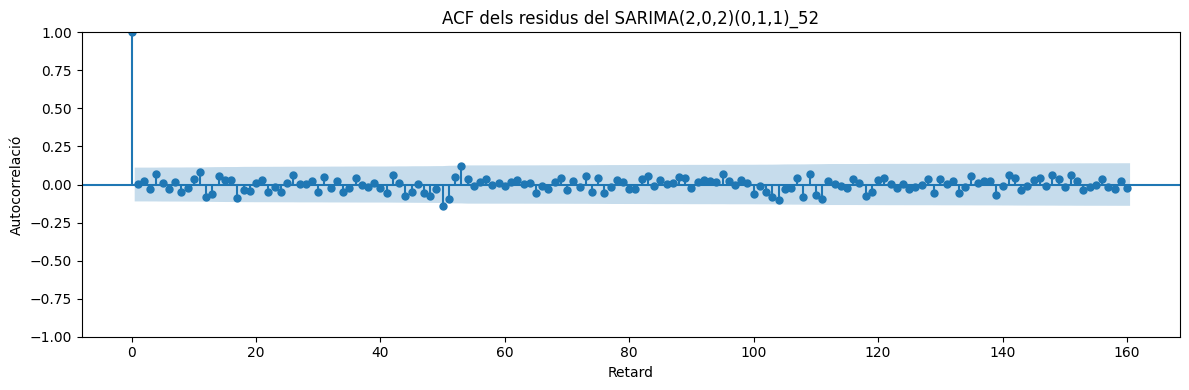


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10   3.938406   0.558318
20  15.360331   0.425787
30  19.630081   0.765951

Test de Ljung-Box en retards estacionals:
       lb_stat  lb_pvalue
52   43.390382   0.622862
104  78.292115   0.938300

Mitjana dels residus: 0.0010689168132201378


In [18]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual1)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(2,0,2)(0,1,1)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual1, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(2,0,2)(0,1,1)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")

plt.tight_layout()
plt.show()


model_df = 2 + 2 + 0 + 1

ljung_box = acorr_ljungbox(
    residual1,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual1,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual1.mean())

Burn-in utilitzat: 107


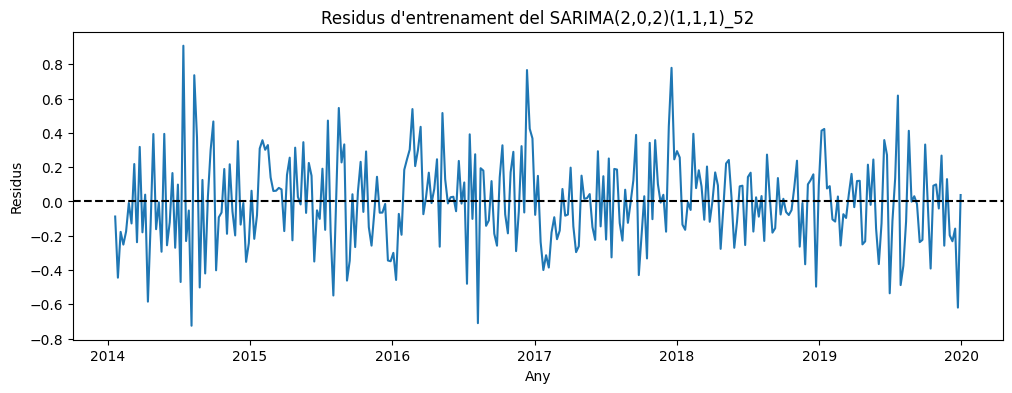

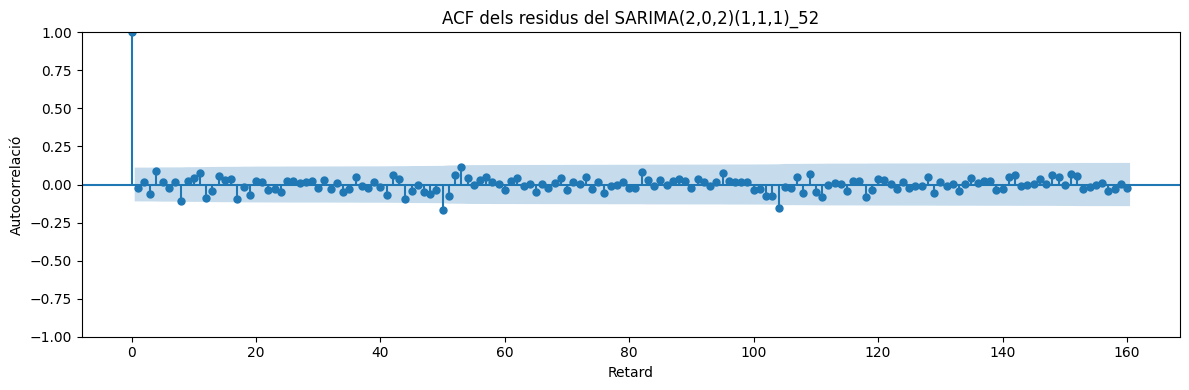


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10   8.668239   0.069949
20  20.495649   0.115273
30  22.960168   0.522151

Test de Ljung-Box en retards estacionals:
       lb_stat  lb_pvalue
52   50.636349   0.295621
104  92.357083   0.641772

Mitjana dels residus: 0.00153161072675665


In [19]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual2)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(2,0,2)(1,1,1)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual2, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(2,0,2)(1,1,1)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")
plt.tight_layout()
plt.show()


model_df = 2 + 2 + 1 + 1

ljung_box = acorr_ljungbox(
    residual2,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual2,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual2.mean())

Burn-in utilitzat: 107


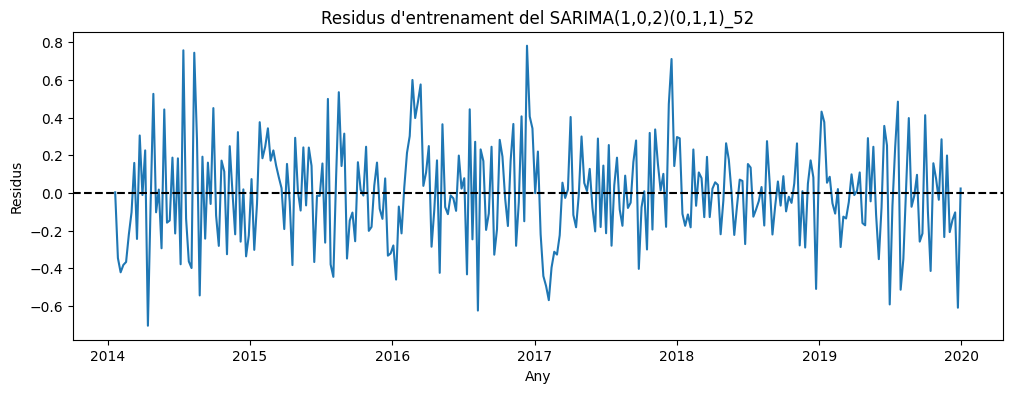

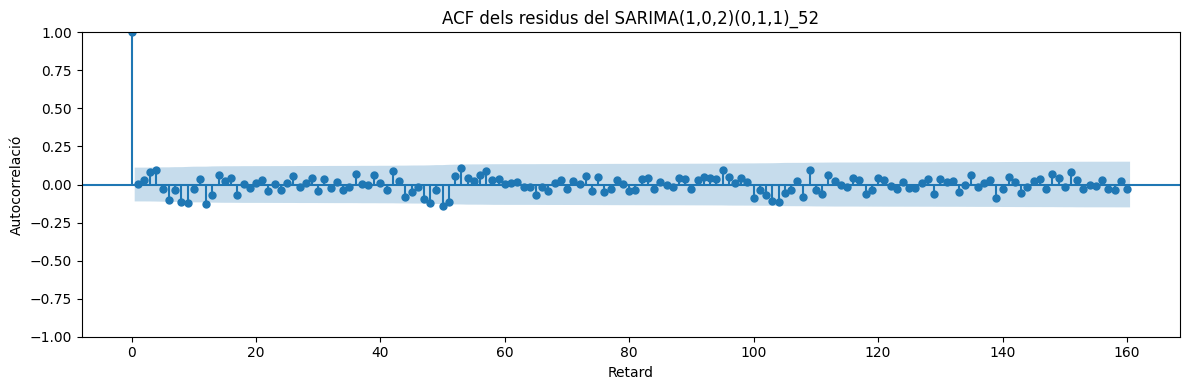


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10  18.196994   0.005758
20  29.193543   0.022663
30  33.150515   0.157776

Test de Ljung-Box en retards estacionals:
        lb_stat  lb_pvalue
52    67.402064   0.033713
104  119.897729   0.085403

Mitjana dels residus: -0.0018280036862710855


In [20]:
residuals= result3.resid.dropna()
burn = max(result3.loglikelihood_burn, result3.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual3 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual3)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(1,0,2)(0,1,1)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual3, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(1,0,2)(0,1,1)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")
plt.tight_layout()
plt.show()


model_df = 1 + 2 + 0 + 1

ljung_box = acorr_ljungbox(
    residual3,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual3,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual3.mean())

### Elecció del model final

El model final seleccionat és SARIMA(2,0,2)(0,1,1)_{52}, ja que presenta el menor AIC entre els models preseleccionats, coeficients significatius i un diagnòstic residual adequat. El model amb component autoregressiva estacional addicional no millora l’ajust segons l’AIC i introdueix més complexitat, mentre que l’altre model candidat presenta un comportament residual menys satisfactori.

## Predicció SARIMA

Amb el model final seleccionat, es generen prediccions per al període 2020-2024 i es comparen amb els valors observats mitjançant el MAE, el RMSE i la cobertura dels intervals de predicció.

In [21]:
model = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log) 

In [22]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)
cov_total = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)
cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)
cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

table_total = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_total],
    "RMSE": [rmse_total],
    "Cobertura": [cov_total]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

table_covid = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_covid],
    "RMSE": [rmse_covid],
    "Cobertura": [cov_covid]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

table_post = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_post],
    "RMSE": [rmse_post],
    "Cobertura": [cov_post]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

print("\nTOTAL (2020-2024):")
display(table_total)

print("\nCOVID (2020–2021):")
display(table_covid)

print("\nPOST-COVID (2022–2024):")
display(table_post)


TOTAL (2020-2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,503.552,780.287,0.585



COVID (2020–2021):


,Model,MAE,RMSE,Cobertura
0,SARIMA,337.324,691.957,0.808



POST-COVID (2022–2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,614.37,833.992,0.436


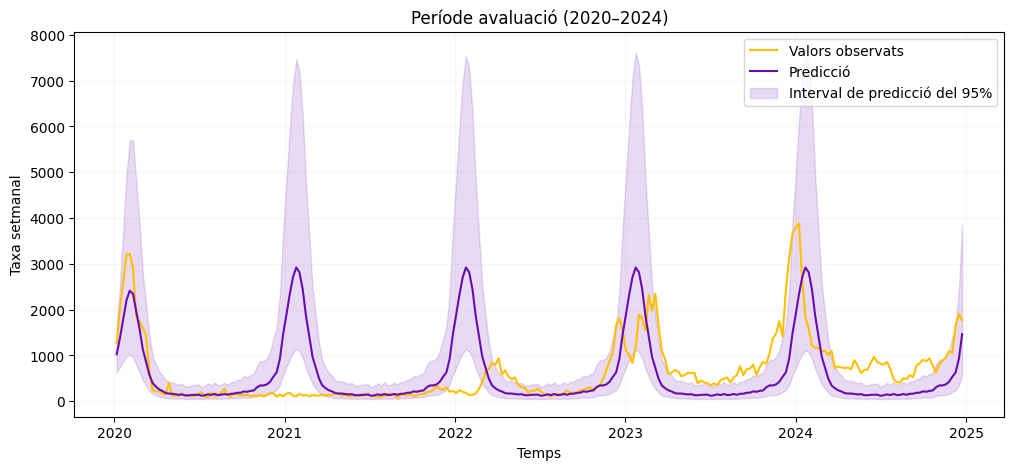

In [23]:
plt.figure(figsize=(12,5))

plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període avaluació (2020–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()

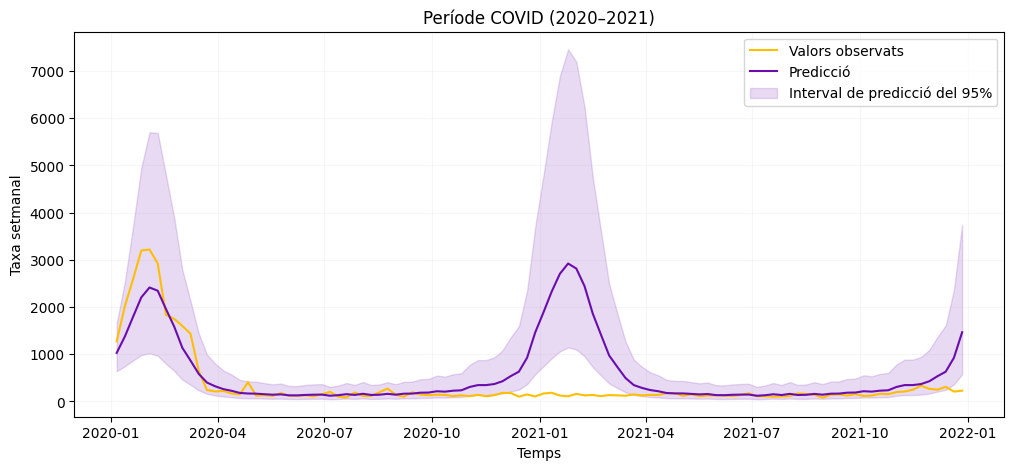

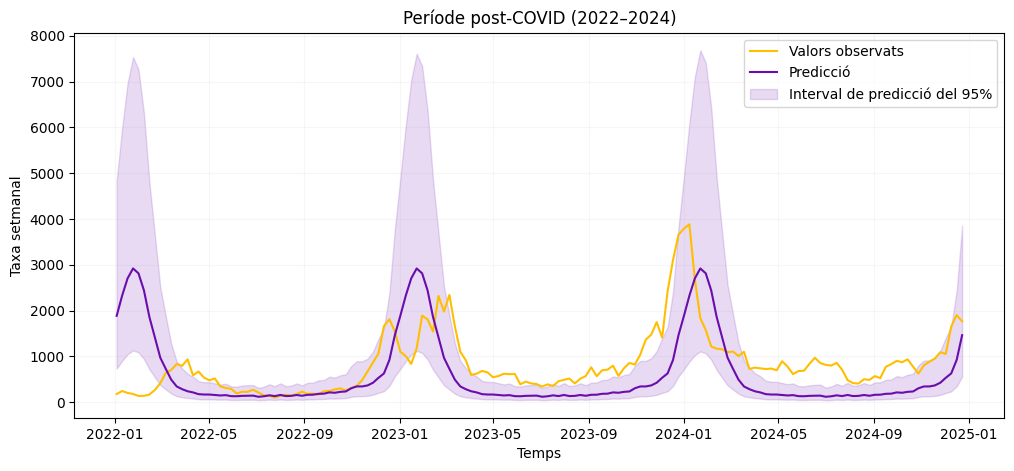

In [24]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període COVID (2020–2021)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període post-COVID (2022–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

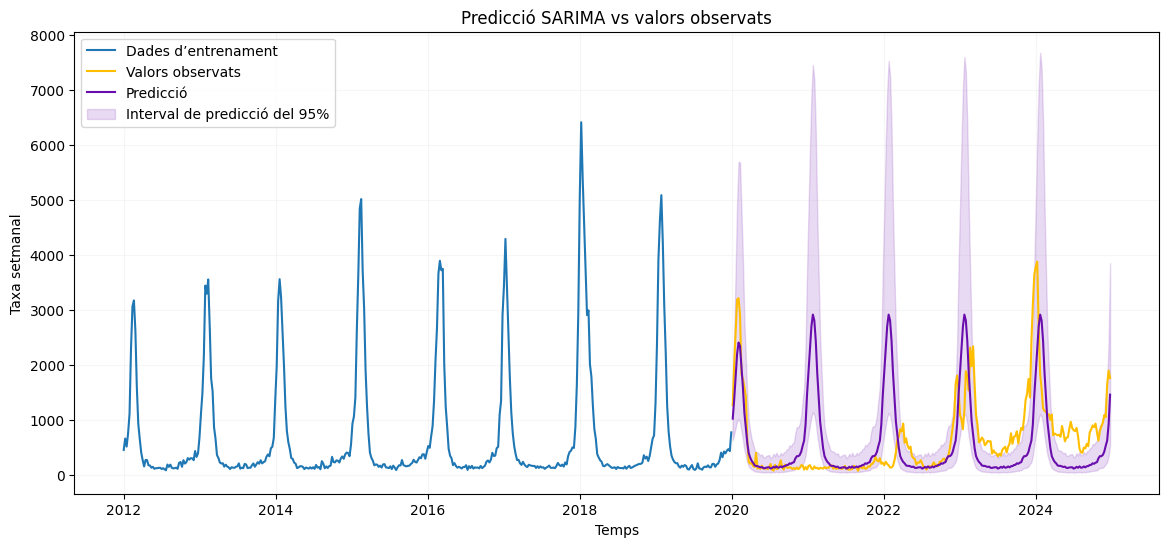

In [25]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Dades d’entrenament', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.legend()
plt.title("Predicció SARIMA vs valors observats")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)
plt.show()